# Time Series Forecasting: ERCOT Electricity Demand

## Objective

The goal of this notebook is to build and evaluate statistical time series forecasting models for ERCOT electricity demand using historical daily data.

## Scope

This notebook focuses on:

- Establishing baseline forecasting models (naive, seasonal naive, moving average)
- Evaluating stationarity using the Augmented Dickey-Fuller (ADF) test
- Developing SARIMA models for univariate forecasting
- Comparing model performance using MAE, RMSE, and MAPE
- Benchmarking results against the EIA day-ahead demand forecast

## Approach

The workflow follows a structured progression:

1. Data preparation and validation (from previous notebooks)
2. Time-based train/validation/test split
3. Baseline model evaluation
4. Statistical modeling using SARIMA
5. Model comparison and performance evaluation

## Key Question

How well can statistical time series models forecast electricity demand compared to simple baselines and real-world forecasts?

---

This notebook builds on the ingestion and EDA steps from previous notebooks in the project.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 2. Load Data (Same as EDA notebook)

In [2]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand")
PROCESSED_DIR = BASE_DIR/"data" / "processed"

df = pd.read_csv(PROCESSED_DIR / "ercot_daily_wide.csv", parse_dates=["period"])

df = df.sort_values("period")
df = df.set_index("period")

# enforce daily frequency
df = df.asfreq("D")

df.head()

,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count
period,,,,,,
2019-01-01,950405.0,932790.0,951051.0,24.0,24.0,24.0
2019-01-02,1093650.0,1038403.0,1091777.0,24.0,24.0,24.0
2019-01-03,1119840.0,1084163.0,1120374.0,24.0,24.0,24.0
2019-01-04,1065428.0,1086500.0,1067670.0,24.0,24.0,24.0
2019-01-05,931268.0,948521.0,935034.0,24.0,24.0,24.0


### 2.1 Data Quality Note

During preprocessing, I identified a missing daily observation caused by daylight saving time irregularities. Since it was a single isolated case, I removed it to maintain modeling stability while preserving overall data integrity.

In [3]:
df = df.asfreq("D")

df_model = df.dropna(subset=["demand"]).copy()

## 3. Target Selection

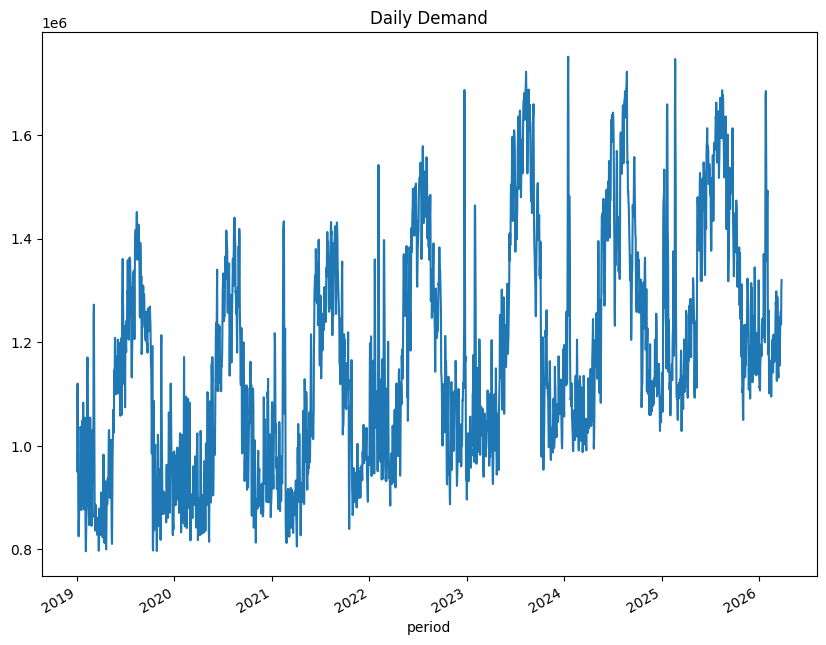

In [4]:
target = "demand"
df_model[target].plot(figsize = (10,8), title = "Daily Demand")
plt.show()

In [5]:
# Check on df NaN values
print(df[target].isna().sum())
print("Missing values in df:", df[df[target].isna()].head())

1
Missing values in df:             demand  demand_forecast  net_generation  demand_count  \
period                                                              
2021-11-07     NaN              NaN             NaN           NaN   

            demand_forecast_count  net_generation_count  
period                                                   
2021-11-07                    NaN                   NaN  


In [6]:
# Confirm on df_model NaN values
print(df_model[target].isna().sum())
print("Missing values in df_model:", df_model[target].isna().sum())

0
Missing values in df_model: 0


## 4. Train / Validation / Test Split (Time-Based)

In [7]:
train_size = int(len(df_model)*0.7)
val_size = int(len(df_model)*0.15)

train = df_model.iloc[:train_size]
val = df_model.iloc[train_size:train_size+val_size]
test = df_model.iloc[train_size+val_size:]

print(len(train), len(val), len(test))

1848 396 397


## 5. Evaluation Function

In [8]:
def evaluate(y_true, y_pred, name="Model"):
    eval_df = pd.concat([y_true, y_pred], axis=1).dropna()
    eval_df.columns = ["actual", "predicted"]

    mae = mean_absolute_error(eval_df["actual"], eval_df["predicted"])
    rmse = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["predicted"]))
    mape = np.mean(np.abs((eval_df["actual"] - eval_df["predicted"]) / eval_df["actual"])) * 100

    print(f"{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 30)

    return mae, rmse, mape

## 6. Baseline Models

### 6.1 Naive

In [9]:
naive_forecast = test[target].shift(1).loc[test.index]
evaluate(test[target], naive_forecast, "Naive")

Naive
MAE: 42227.27
RMSE: 55697.25
MAPE: 3.23%
------------------------------


(42227.270202020205,
 np.float64(55697.24741305816),
 np.float64(3.228316598372821))

### 6.2 Seasonal Naive (weekly pattern - lag 7)

In [10]:
seasonal_naive = test[target].shift(7).loc[test.index]

evaluate(test[target], seasonal_naive, "Seasonal Naive (7-day)")

Seasonal Naive (7-day)
MAE: 83876.79
RMSE: 108684.94
MAPE: 6.40%
------------------------------


(83876.78717948718,
 np.float64(108684.94327339472),
 np.float64(6.3968763194601275))

### 6.3 Moving Average (7-day)

In [11]:
# Check on moving avg for 7 days
print(train[target].rolling(7).mean())

period
2019-01-01             NaN
2019-01-02             NaN
2019-01-03             NaN
2019-01-04             NaN
2019-01-05             NaN
                  ...     
2024-01-19    1.470888e+06
2024-01-20    1.505125e+06
2024-01-21    1.507377e+06
2024-01-22    1.457436e+06
2024-01-23    1.375298e+06
Name: demand, Length: 1848, dtype: float64


In [12]:
moving_avg_forecast = df_model[target].rolling(7).mean().shift(1).loc[test.index]
moving_avg_forecast = pd.Series(moving_avg_forecast, index = test.index)
evaluate(test[target], moving_avg_forecast, "Moving Average (7 Day rolling, No leakage!)")

Moving Average (7 Day rolling, No leakage!)
MAE: 62521.61
RMSE: 84909.18
MAPE: 4.81%
------------------------------


(62521.60561353006,
 np.float64(84909.17846781567),
 np.float64(4.809942581013912))

In [13]:
test[target].shape, moving_avg_forecast.shape

((397,), (397,))

### 6.4 ADF Test (Stationary Check)

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train[target].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.0031114669394268
p-value: 0.03460484833311323


## 7. SARIMA (Univariate Model)

In [15]:
model = SARIMAX(
    train[target],
    order=(1,1,1),

    # weekly seasonality
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fitting Sarima
results = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 7.1 Model Summary (AIC / BIC / Coefficients)

In [16]:
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            demand   No. Observations:                 1848
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -22902.487
Date:                           Fri, 24 Apr 2026   AIC                          45814.973
Time:                                   03:27:15   BIC                          45842.536
Sample:                                        0   HQIC                         45825.139
                                          - 1848                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2798      0.067     -4.192      0.000      -0.411      -0.149
ma.L1          0.5931      0.056     10.542

## 8. Forecast

In [17]:
# Check on test index
test.index

DatetimeIndex(['2025-02-23', '2025-02-24', '2025-02-25', '2025-02-26',
               '2025-02-27', '2025-02-28', '2025-03-01', '2025-03-02',
               '2025-03-03', '2025-03-04',
               ...
               '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20',
               '2026-03-21', '2026-03-22', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-26'],
              dtype='datetime64[ns]', name='period', length=397, freq=None)

In [18]:
forecast_obj = results.get_forecast(steps=len(test))

# To drop the index at forecast, converted series to an array
sarima_forecast = forecast_obj.predicted_mean
sarima_forecast = pd.Series(np.asarray(sarima_forecast), index=test.index, name="sarima_forecast")

print(sarima_forecast.head())
print("NaNs:", sarima_forecast.isna().sum())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


period
2025-02-23    1.085427e+06
2025-02-24    1.011949e+06
2025-02-25    9.849741e+05
2025-02-26    1.045180e+06
2025-02-27    1.060989e+06
Name: sarima_forecast, dtype: float64
NaNs: 0


In [19]:
# Forecast object check
forecast_obj.predicted_mean[:10]

,predicted_mean
1848,1.085427e+06
1849,1.011949e+06
1850,9.849741e+05
1851,1.045180e+06
1852,1.060989e+06
1853,1.126290e+06
1854,1.150429e+06
1855,1.107901e+06
1856,9.960222e+05
1857,9.699880e+05


In [20]:
sarima_forecast[:10]

,sarima_forecast
period,
2025-02-23,1.085427e+06
2025-02-24,1.011949e+06
2025-02-25,9.849741e+05
2025-02-26,1.045180e+06
2025-02-27,1.060989e+06
2025-02-28,1.126290e+06
2025-03-01,1.150429e+06
2025-03-02,1.107901e+06
2025-03-03,9.960222e+05


## 9. Evaluate SARIMA

In [21]:
evaluate(test[target], sarima_forecast, "SARIMA")

SARIMA
MAE: 1287288.80
RMSE: 1430013.43
MAPE: 98.04%
------------------------------


(1287288.802357455,
 np.float64(1430013.4312608337),
 np.float64(98.0394212156547))

### 9.1 Sarima Best Configuration

In [22]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [23]:
sarima_specs = [
    ((1,0,1), (1,0,1,7)),
    ((2,0,1), (1,0,1,7)),
    ((1,0,2), (1,0,1,7)),
    ((2,0,2), (1,0,1,7)),
    ((1,1,1), (0,0,1,7)),
    ((1,0,1), (0,1,1,7)),
]


In [24]:
results_list = []

for order, seasonal_order in sarima_specs:
    try:
        model = SARIMAX(
            train[target],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)
        forecast = fit.get_forecast(steps=len(test)).predicted_mean
        forecast = pd.Series(np.asarray(forecast), index=test.index)

        mae, rmse, mape = evaluate(test[target], forecast, f"SARIMA{order}x{seasonal_order}")

        results_list.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    except Exception as e:
        print(order, seasonal_order, "failed:", e)

sarima_results = pd.DataFrame(results_list).sort_values("MAPE")
sarima_results

SARIMA(1, 0, 1)x(1, 0, 1, 7)
MAE: 881194.72
RMSE: 930901.80
MAPE: 65.99%
------------------------------
SARIMA(2, 0, 1)x(1, 0, 1, 7)
MAE: 975367.73
RMSE: 1017817.19
MAPE: 73.16%
------------------------------
SARIMA(1, 0, 2)x(1, 0, 1, 7)
MAE: 458187.71
RMSE: 503557.56
MAPE: 33.72%
------------------------------
SARIMA(2, 0, 2)x(1, 0, 1, 7)
MAE: 350680.22
RMSE: 394521.23
MAPE: 25.61%
------------------------------
SARIMA(1, 1, 1)x(0, 0, 1, 7)
MAE: 263929.80
RMSE: 315854.29
MAPE: 18.64%
------------------------------
SARIMA(1, 0, 1)x(0, 1, 1, 7)
MAE: 173041.02
RMSE: 215205.89
MAPE: 12.43%
------------------------------


,order,seasonal_order,AIC,BIC,MAE,RMSE,MAPE
5,"(1, 0, 1)","(0, 1, 1, 7)",45659.692866,45681.745520,173041.020573,2.152059e+05,12.430930
4,"(1, 1, 1)","(0, 0, 1, 7)",45667.337300,45689.403033,263929.800891,3.158543e+05,18.635036
3,"(2, 0, 2)","(1, 0, 1, 7)",45734.053693,45772.668726,350680.215500,3.945212e+05,25.605573
2,"(1, 0, 2)","(1, 0, 1, 7)",45587.751909,45620.850509,458187.708170,5.035576e+05,33.724168
0,"(1, 0, 1)","(1, 0, 1, 7)",45704.227501,45731.812387,881194.722879,9.309018e+05,65.985561
1,"(2, 0, 1)","(1, 0, 1, 7)",46222.341090,46255.442953,975367.729970,1.017817e+06,73.159799


### 9.2 Re-Fit Sarima with Best Configuration

In [25]:
best_order = (1, 0, 1)
best_seasonal_order = (0, 1, 1, 7)

best_sarima_model = SARIMAX(
    train[target],
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_sarima_results = best_sarima_model.fit(disp=False)

best_forecast_obj = best_sarima_results.get_forecast(steps=len(test))

best_sarima_forecast = pd.Series(
    np.asarray(best_forecast_obj.predicted_mean),
    index=test.index,
    name="best_sarima_forecast"
)

evaluate(test[target], best_sarima_forecast, "Best SARIMA")

Best SARIMA
MAE: 173041.02
RMSE: 215205.89
MAPE: 12.43%
------------------------------


(173041.0205734846,
 np.float64(215205.8930634988),
 np.float64(12.430929648008739))

## 10. EIA Comparison

In [26]:
evaluate(test[target], test["demand_forecast"], "EIA Forecast")

EIA Forecast
MAE: 26802.90
RMSE: 82370.49
MAPE: 2.08%
------------------------------


(26802.899244332493,
 np.float64(82370.49469708385),
 np.float64(2.080267753243493))

## 11. Forecast Comparison (Best SARIMA vs EIA) - Visualization

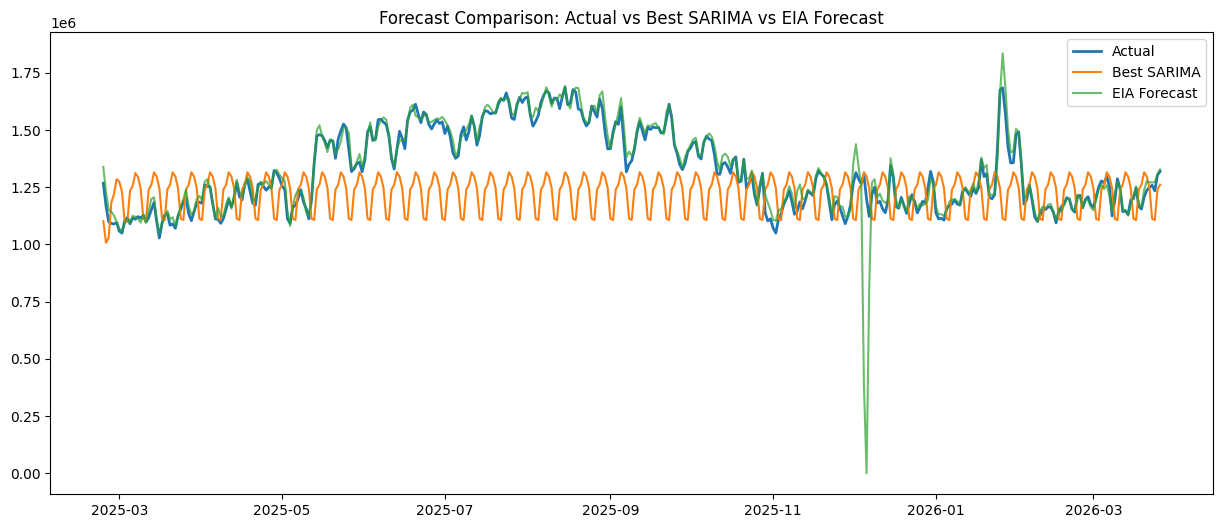

In [27]:
plt.figure(figsize=(15,6))

plt.plot(test.index, test[target], label="Actual", linewidth=2)
plt.plot(test.index, best_sarima_forecast, label="Best SARIMA")
plt.plot(test.index, test["demand_forecast"], label="EIA Forecast", alpha=0.7)

plt.legend()
plt.title("Forecast Comparison: Actual vs Best SARIMA vs EIA Forecast")
plt.show()

## Key Findings

### Model Performance

- The naive model performed strongly (MAPE ≈ 3.2%), indicating that electricity demand has strong short-term dependencies.
- The seasonal naive model (7-day lag) underperformed, suggesting that weekly repetition is less predictive than recent demand levels.
- The moving average baseline showed moderate performance but lagged behind rapid demand changes.

### SARIMA Model Insights

- The initial SARIMA(1,1,1)(1,1,1,7) model produced unstable forecasts with very high error (MAPE ≈ 98%), indicating poor model fit.
- Multiple SARIMA configurations were tested, and the best-performing model, SARIMA(1,0,1)(0,1,1,7), achieved a MAPE of approximately 12.4%.
- While tuning improved performance significantly, SARIMA still underperformed compared to simpler baseline models.
- This suggests that the demand series is dominated by short-term dynamics rather than strong, stable seasonal patterns.

### Comparison with EIA Forecast

- The EIA day-ahead forecast significantly outperformed all statistical models (MAPE ≈ 2.1%).
- The visualization shows that the EIA forecast closely tracks actual demand, while SARIMA exhibits lag and smoothing behavior. :contentReference[oaicite:5]{index=5}
- This highlights the advantage of domain-informed forecasting methods that incorporate external signals such as weather and system conditions.

### Key Observations

- Electricity demand is highly influenced by recent values (lag-1 effect), explaining the strong performance of the naive model.
- Weekly seasonality exists but is relatively weak compared to short-term fluctuations.
- Traditional statistical models like SARIMA may struggle to generalize over long forecast horizons in this dataset.

### Data Quality Note

- A missing observation on 2021-11-07 was identified due to daylight saving time adjustments.
- This row was removed to ensure modeling stability while preserving overall data integrity.

### Next Steps

- Extend the modeling approach using exogenous variables (SARIMAX), such as net generation and demand forecast.
- Develop machine learning models (e.g., XGBoost) using lag and rolling features.
- Evaluate whether ML models can better capture nonlinear patterns and improve long-horizon forecasting performance.